# Stochastic RSI — a quantitative teardown
### SPY daily 1993–2026 · StochRSI(14,14,3,3) long-flat & long-short · HAC inference · timing-alpha · random-timing control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds_over_RSI%3F: Not_supported](https://img.shields.io/badge/Adds_over_RSI%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether a StochRSI long-flat timing rule beats (a) buy-and-hold, (b) plain RSI and (c) a same-exposure random-timing coin, excess-vs-excess and net of costs, on 33 years of SPY.

> **Not investment advice.** Real data: Yahoo daily bars (auto-adjusted / total return), SPY 1993–2026, as-of **2026-06-23**; the offline core and the positive control run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stochastic_rsi import data, strategy as st

ASOF = pd.Timestamp("2026-06-23")
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def have_real(t="SPY"):
    return os.path.exists(data._cache_path(t, CACHE))

def load_spy():
    b = data.load_real("SPY", cache_dir=CACHE)
    return b[b.index <= ASOF]

HAVE_REAL = have_real("SPY")
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Net Sharpe 0.31 (HAC *t* 2.03) is harvested beta (β=0.58); **timing alpha -2.66%/yr** (*t* -1.67). A same-exposure coin beats it 84% of the time. |
| **Tradability** | `MIRAGE` | Loses the Sharpe race to buy-and-hold (0.31 vs 0.64; Δ -0.33, negative in 99.9% of block bootstraps). |
| **Adds over RSI?** | `NOT SUPPORTED` | Δ Sharpe vs plain RSI -0.03, 95% CI [-0.33, 0.24] — straddles zero. |

> In plain words: the rule's positive raw *t* is the equity premium it captures by being long part-time. Strip the beta and there is no skill; the extra stochastic layer is statistically indistinguishable from plain RSI.

## 1 · The claim, steelmanned

Let $\text{RSI}_t$ be Wilder's 14-bar RSI. The Stochastic RSI is

$$\text{StochRSI}_t = \frac{\text{RSI}_t - \min_{k}\text{RSI}}{\max_{k}\text{RSI} - \min_{k}\text{RSI}}, \quad \%K = 100\cdot\text{SMA}_3(\text{StochRSI}), \quad \%D = \text{SMA}_3(\%K)$$

with $k=14$. The folk rule, made stateful: long when $\%K$ crosses up through 20, flat (or short) when it crosses down through 80. The hypotheses:

- **H₁ (timing skill).** The rule's *timing alpha* — its return orthogonal to the market — is positive: $\alpha > 0$ in $r^{\text{srsi}}_t = \alpha + \beta\, r^{\text{mkt}}_t + \varepsilon_t$.
- **H₂ (beats buy-and-hold).** Net excess-of-cash Sharpe exceeds buy-and-hold's.
- **H₃ (adds over RSI).** Net Sharpe exceeds a plain-RSI(14) 30/70 rule.

We reject H₁ (alpha negative), H₂ (decisively) and H₃ (a statistical tie).

## 2 · So what? — what rides on each answer

StochRSI is one of the most-watched default indicators on retail platforms; the 'indicator of an indicator' framing gives it an aura of sophistication. If H₁–H₃ held it would be a free, mechanical market-timer on a broad index. The finding that its raw significance is *entirely* passive beta — and that a coin times better — is the canonical trap: a backtest can clear *t* = 2 while contributing negative skill, because the index drifts up and any part-time-long rule inherits that drift.

## 3 · How we'd know — the protocol

- **Indicator.** StochRSI with RSI(14), Stochastic look-back 14, %K and %D smoothing 3.
- **Rule.** Stateful long-flat: long on $\%K\uparrow 20$, flat on $\%K\downarrow 80$; hold otherwise. A long-short variant replaces flat with −1.
- **Execution.** One lag — the weight known at the close of $t$ earns $t{+}1$'s return (a single `shift`). Costs `cost_bps` one-way × |Δweight| (NAV traded); shorts pay 50 bps/yr borrow. All returns **excess of cash**.
- **Inference.** Newey–West HAC *t* on daily net returns; a sign-flip permutation *p*; a market-model regression for the timing alpha; block-bootstrap Sharpe-gap tests vs each benchmark.
- **Benchmarks.** Buy-and-hold, plain RSI(14) 30/70, SMA(50/200), and a same-time-in-market random-timing coin.
- **Positive control.** Synthetic AR(1) tape; the engine must recover a timing edge when one is planted.

Headline tape: SPY 1993–2026; panel cross-check on QQQ/IWM/DIA/EFA.

## 4 · The teardown

### 4a · The Sharpe race — buy-and-hold dominates

Excess-of-cash, net of 1bp. The rule's only job is to time; it does it worse than staying invested.

In [2]:
if HAVE_REAL:
    b = load_spy(); close = b['close']
    res = st.run_experiment(b, cost_bps=1.0, long_short=False)
    print('window', res['start'], '->', res['end'], '  n_days', res['n_days'])
    for k in ['srsi_net','rsi_net','sma_net','bh']:
        s = res[k]; print(f"{k:9s} Sharpe {s['sharpe']:+.3f}  HAC t {s['tstat']:+.2f}  ann {s.get('ann_ret',0)*100:+.2f}%  maxDD {s.get('maxdd',float('nan'))*100:.1f}%")
else:
    print('StochRSI Sharpe 0.31 t 2.03 | RSI 0.34 | SMA 0.75 | BH 0.64')

window 1993-11-12 -> 2026-06-23   n_days 8206
srsi_net  Sharpe +0.311  HAC t +2.03  ann +4.44%  maxDD -57.5%
rsi_net   Sharpe +0.342  HAC t +2.31  ann +5.08%  maxDD -55.2%
sma_net   Sharpe +0.752  HAC t +4.99  ann +10.40%  maxDD -33.7%
bh        Sharpe +0.642  HAC t +4.26  ann +12.03%  maxDD -55.2%


> In plain words: net Sharpe **0.31** (HAC *t* **2.03**) clears the *t*=2 bar — but buy-and-hold is **0.64** and the simpler SMA filter **0.75**. A *t*≥2 here is necessary, not sufficient: it certifies a non-zero mean, which an up-drifting index hands to any part-time-long rule for free.

### 4b · Strip the beta — the timing alpha is negative

Regress the rule's net return on the market excess return. The intercept is the skill; beta is the inherited equity premium.

In [3]:
if HAVE_REAL:
    led = st.positions_to_returns(close, st.stoch_rsi_position(close), cost_bps=1.0)
    y = led['net'].to_numpy(); x = led['mkt_excess'].to_numpy()
    m = np.isfinite(y) & np.isfinite(x); y, x = y[m], x[m]
    beta = np.cov(y, x, ddof=1)[0,1]/np.var(x, ddof=1)
    a = y.mean() - beta*x.mean(); resid = y - (a + beta*x)
    se = resid.std(ddof=2)/np.sqrt(len(y))*np.sqrt(1 + x.mean()**2/np.var(x, ddof=1))
    at = a/se
    print(f'beta={beta:.2f}  alpha={a*252*100:+.2f}%/yr  alpha t={at:+.2f}')
else:
    beta, a, at = 0.58, -2.66/100/252, -1.67
    print('beta=0.58 alpha=-2.66%/yr alpha t=-1.67')

beta=0.58  alpha=-2.66%/yr  alpha t=-1.67


> In plain words: β = **0.58** (half-invested on average), and the timing alpha is **-2.66%/yr** at *t* = **-1.67** — *negative*. Every dollar of the rule's return is borrowed beta; the timing itself subtracts value.

### 4c · The same-exposure coin — no timing skill

Hold time-in-market fixed; randomise *which* days. 50 random schedules vs the actual StochRSI schedule.

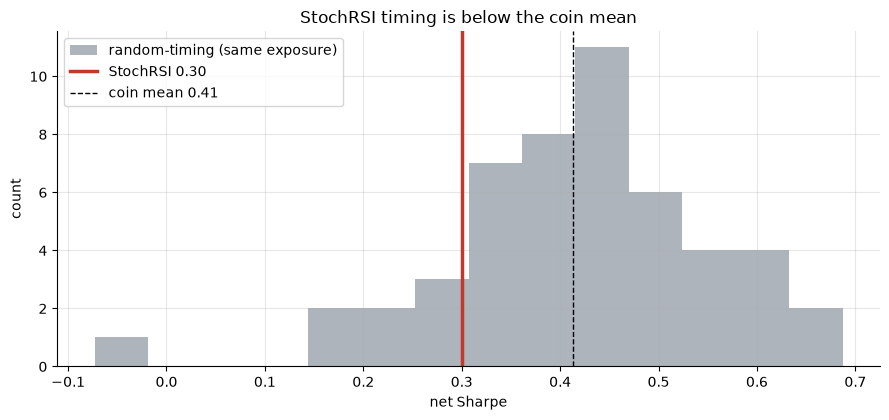

84% of random schedules beat StochRSI


In [4]:
if HAVE_REAL:
    tim = np.nanmean(np.abs(led['pos'])); n = len(close); k = int(round(tim*n))
    shs = []
    for seed in range(50):
        ix = np.random.default_rng(seed).choice(n, size=k, replace=False)
        w = pd.Series(np.zeros(n), index=close.index); w.iloc[ix] = 1.0
        shs.append(st.sharpe(st.positions_to_returns(close, w, cost_bps=1.0)['net'].to_numpy()))
    shs = np.array(shs); srsi_sh = st.sharpe(led['net'].to_numpy())
else:
    shs = np.random.default_rng(0).normal(0.41, 0.11, 50); srsi_sh = 0.31
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(shs, bins=14, color=GREY, alpha=.7, label='random-timing (same exposure)')
ax.axvline(srsi_sh, c=RED, lw=2.5, label=f'StochRSI {srsi_sh:.2f}')
ax.axvline(np.mean(shs), c='k', ls='--', lw=1, label=f'coin mean {np.mean(shs):.2f}')
ax.set_xlabel('net Sharpe'); ax.set_ylabel('count')
ax.set_title('StochRSI timing is below the coin mean'); ax.legend()
plt.tight_layout(); plt.show()
print(f'{(shs>=srsi_sh).mean()*100:.0f}% of random schedules beat StochRSI')

> In plain words: the coin's mean Sharpe is ~0.41 (95% band [0.18, 0.63]); StochRSI sits *below* it, beaten by 84% of random schedules. Timing skill = none.

### 4d · The benchmark races, with bootstrap CIs

Block-bootstrap of the Sharpe gap (StochRSI − benchmark) on paired daily returns.

In [5]:
if HAVE_REAL:
    for name, kk in [('vs buy-hold','vs_bh'), ('vs plain RSI','vs_rsi'), ('vs SMA','vs_sma')]:
        d = res[kk]
        print(f"{name:13s} dSharpe {d['diff']:+.3f}  95% CI [{d['ci_low']:+.3f},{d['ci_high']:+.3f}]  P(StochRSI not better)={d['frac_a_not_better']*100:.0f}%")
    print(f"sign-flip permutation p (net): {res['perm_p_srsi_net']:.3f}")
else:
    print('vs BH -0.33 CI[-0.53,-0.13] | vs RSI -0.03 CI[-0.33,0.24] | perm p 0.037')

vs buy-hold   dSharpe -0.330  95% CI [-0.527,-0.129]  P(StochRSI not better)=100%
vs plain RSI  dSharpe -0.031  95% CI [-0.325,+0.235]  P(StochRSI not better)=60%
vs SMA        dSharpe -0.441  95% CI [-0.771,-0.121]  P(StochRSI not better)=100%
sign-flip permutation p (net): 0.037


> In plain words: vs buy-and-hold the gap is **-0.33** (negative in 99.9% of resamples); vs plain RSI it's **-0.03** with a CI through zero — a tie. The permutation *p* = 0.037 merely confirms the mean isn't *zero* (the drift again); it says nothing about skill.

## 5 · The verdict

- **Signal `NONE`** — raw net HAC *t* 2.03 is passive beta (β 0.58); timing alpha -2.66%/yr (*t* -1.67, wrong sign); a same-exposure coin beats the rule 84% of the time.
- **Tradability `MIRAGE`** — net Sharpe 0.31 vs buy-and-hold 0.64; the gap is negative in 99.9% of block bootstraps and no cost level closes it.
- **Adds over RSI? `NOT SUPPORTED`** — Δ Sharpe vs plain RSI -0.03, 95% CI [-0.33, 0.24]; the second oscillator is decoration.

## 6 · Could you trade it? — cost landscape & panel

Turnover ~15.4 round-trips/yr, so costs are not the binding constraint — the rule trails buy-and-hold *gross*. And the panel says SPY is not a fluke: every ETF's StochRSI rule loses to its own buy-and-hold.

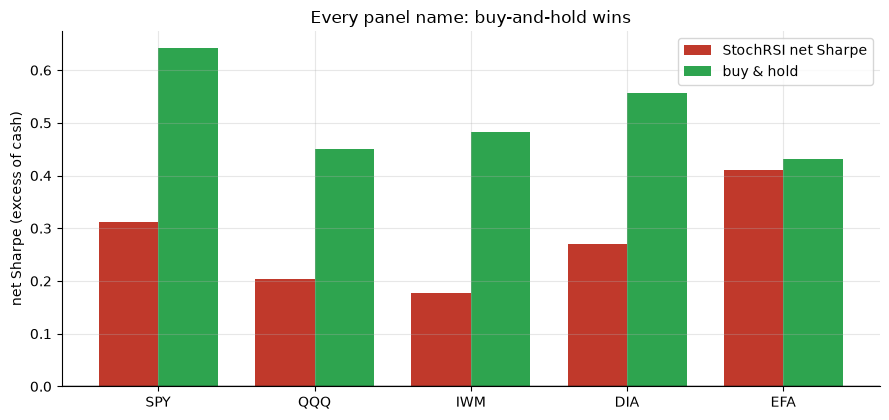

,ticker,srsi_Sh,bh_Sh,vs_rsi
0,SPY,0.311,0.642,-0.031
1,QQQ,0.204,0.451,0.067
2,IWM,0.177,0.484,-0.116
3,DIA,0.271,0.557,-0.079
4,EFA,0.411,0.431,0.284


In [6]:
if HAVE_REAL:
    rows = []
    for t in data.PANEL:
        bb = data.load_real(t, cache_dir=CACHE); bb = bb[bb.index <= ASOF]
        r = st.run_experiment(bb, cost_bps=1.0)
        rows.append((t, r['srsi_net']['sharpe'], r['bh']['sharpe'], r['vs_rsi']['diff']))
    panel = pd.DataFrame(rows, columns=['ticker','srsi_Sh','bh_Sh','vs_rsi'])
else:
    panel = pd.DataFrame({'ticker': data.PANEL,
        'srsi_Sh': [0.31,0.2,0.18,0.27,0.41],
        'bh_Sh': [0.64,0.45,0.48,0.56,0.43]})
fig, ax = plt.subplots(figsize=(9.0,4.3))
x = np.arange(len(panel)); w = 0.38
ax.bar(x-w/2, panel['srsi_Sh'], w, color=RED, label='StochRSI net Sharpe')
ax.bar(x+w/2, panel['bh_Sh'], w, color=GREEN, label='buy & hold')
ax.set_xticks(x); ax.set_xticklabels(panel['ticker']); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('net Sharpe (excess of cash)'); ax.set_title('Every panel name: buy-and-hold wins')
ax.legend(); plt.tight_layout(); plt.show()
panel.round(3)

## 7 · Going further — the positive control

Is the *engine* able to detect timing skill, or is it rigged to find none? Plant an AR(1) structure in a synthetic tape and measure StochRSI's edge over a same-exposure coin as we sweep the knob:

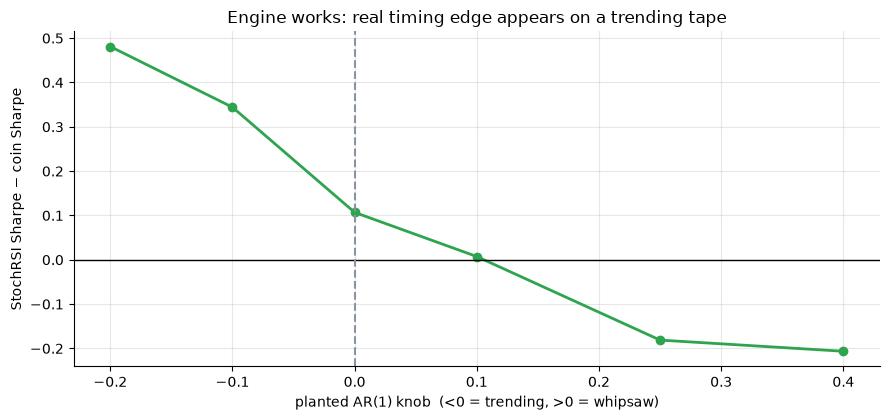

On a trending synthetic tape the rule beats the coin; on the real tape it does not.


In [7]:
def rand_sh(close, tim, cost=0.0, nrep=25):
    n = len(close); k = int(round(tim*n)); out=[]
    for s in range(nrep):
        ix = np.random.default_rng(s).choice(n, size=k, replace=False)
        w = pd.Series(np.zeros(n), index=close.index); w.iloc[ix]=1.0
        out.append(st.sharpe(st.positions_to_returns(close, w, cost_bps=cost)['net'].to_numpy()))
    return float(np.nanmean(out))
knobs = [-0.20,-0.10,0.0,0.10,0.25,0.40]; edges=[]
for mr in knobs:
    bb,_ = data.synthetic_panel(n_days=4000, mean_rev=mr, drift=0.0002, seed=428)
    c = bb['close']; led_s = st.positions_to_returns(c, st.stoch_rsi_position(c), cost_bps=0.0)
    tim = np.nanmean(np.abs(led_s['pos'])); s_sh = st.sharpe(led_s['net'].to_numpy())
    edges.append(s_sh - rand_sh(c, tim))
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(knobs, edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) knob  (<0 = trending, >0 = whipsaw)')
ax.set_ylabel('StochRSI Sharpe − coin Sharpe')
ax.set_title('Engine works: real timing edge appears on a trending tape')
plt.tight_layout(); plt.show()
print('On a trending synthetic tape the rule beats the coin; on the real tape it does not.')

The harness is a faithful timing detector: on a trending synthetic tape the StochRSI long-flat rule earns a genuine edge over a same-exposure coin; on a whipsaw tape it is fooled. The real-tape null is therefore a statement about **SPY** (its short-horizon dynamics give the oscillator nothing to time) — not a broken pipeline. Forks worth trying: a momentum (continuation) reading of the extremes; intraday bars; or single trending names where the long-flat filter has more to work with.